/ut3/haru/miniconda2/envs/py3.10/lib/python3.10/site-packages/pytools/persistent_dict.py:52: RecommendedHashNotFoundWarning: Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.
  warn("Unable to import recommended hash 'siphash24.siphash13', "


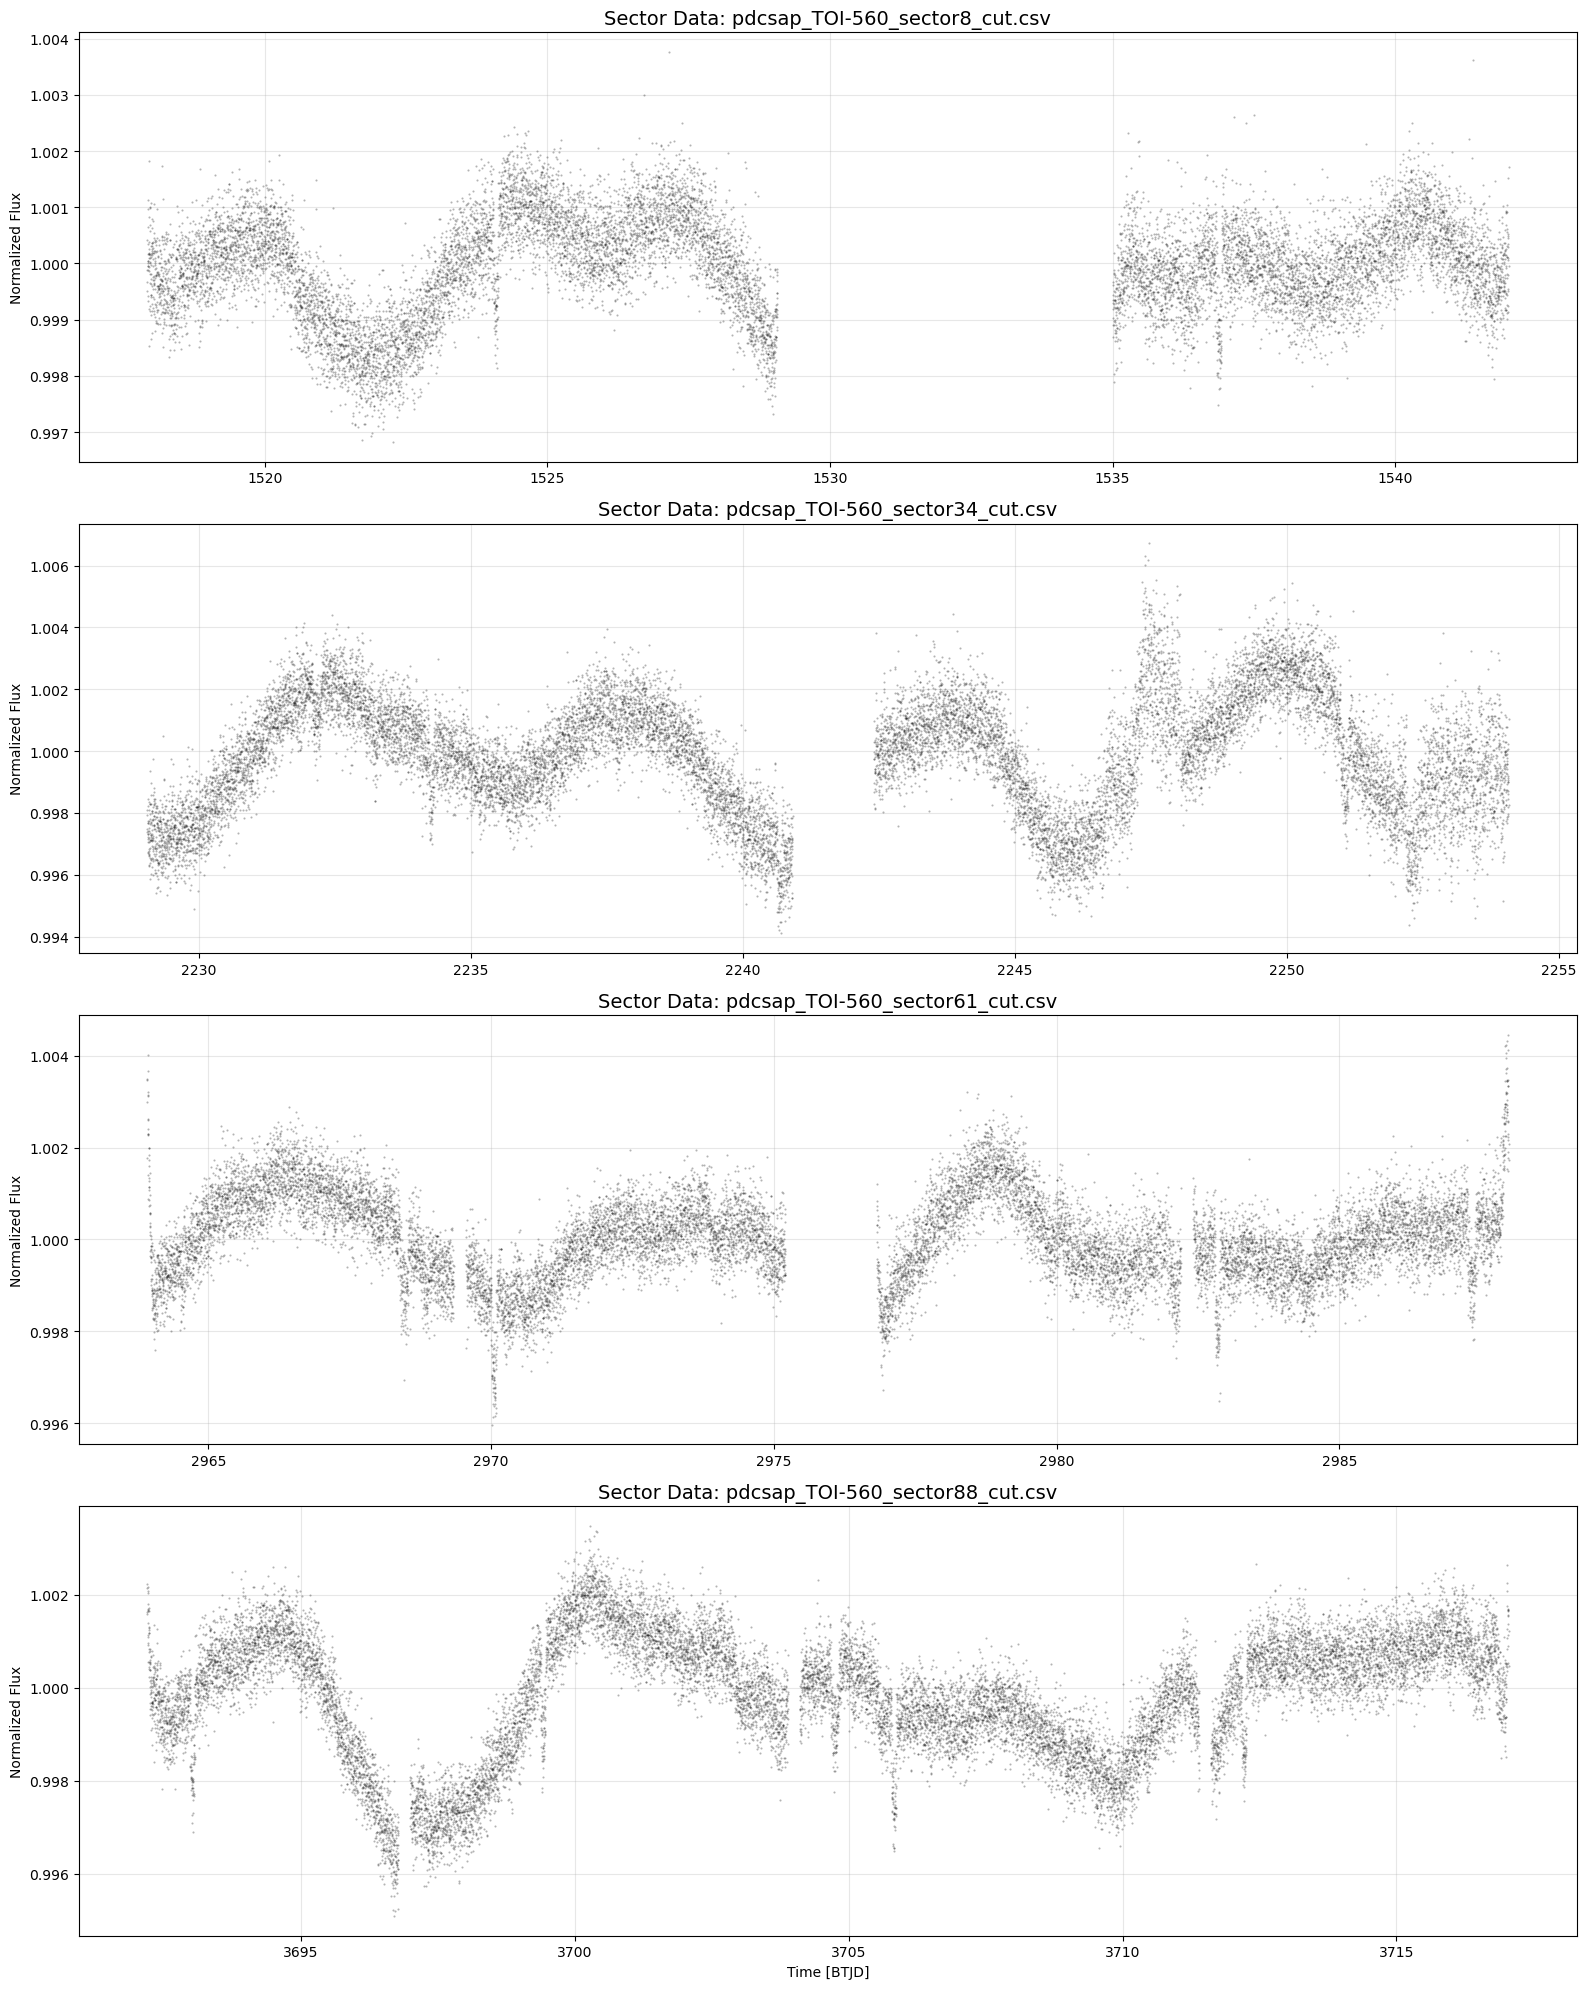

Total data points (ndata_tot): 63040
1517.421417 3760.611359700727
[  1.   3. 112. 113. 169. 171. 173. 175. 176. 179. 221. 223. 224. 227.
 227. 229. 231. 233. 279. 289. 296. 337. 339. 340. 341. 342. 343. 345.
 346. 349.] [ 37.  38.  57.  58.  74.  76.  76.  77.  77.  78.  99. 113. 114. 115.
 115. 116. 117.]
[[0, 2], [111, 112, 113, 114], [226, 228], [339, 340, 341, 342]]
[[], [0, 1], [39, 40], [78]]


In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
import corner
import celerite
from celerite import terms
from celerite.modeling import Model
from multiprocessing import Pool
from ttvfast import models, ttvfast
from pytransit import QuadraticModel
from ldtk import LDPSetCreator, BoxcarFilter
import time
os.environ['OMP_NUM_THREADS']='1'
os.nice(19)

# --- 1. 定数・物理パラメータの定義 ---
G_SI = 6.67428e-14
M_SUN = 1.988e33  # g
R_SUN = 6.96e8    # m
M_EARTH_SUN = 332946.0  # 地球質量/太陽質量

# Barragán+21 等に基づく主星パラメータ
MS = 0.73   # M_sun
MSE = 0.02
RS = 0.65   # R_sun
RSE = 0.02

# 平均密度の事前分布計算
rhos0 = 3 * MS * M_SUN / (4 * np.pi * (RS * R_SUN)**3)
rhos0e = np.sqrt((rhos0 / MS * MSE)**2 + (3 / RS * rhos0 * RSE)**2)
lnrhos0 = np.log(rhos0)
lnrhos0e = rhos0e / rhos0

# 惑星の公転周期と基準時刻 (初期値)
P1, Tc01 = 6.39804982, 1524.088335  # Planet b
P2, Tc02 = 18.8792444, 2232.168625  # Planet c
P1_lin, P2_lin = P1, P2
Tc1_err, Tc2_err = 1, 1 # TTV許容誤差 [day]

# --- 2. データの読み込み設定 ---
lc_dir = '../tess'
listfile = os.path.join(lc_dir, 'pdcsap_list.txt')

# ダミーデータ生成（ファイルがない場合の構造確認用。実際は読み込みを優先）
if not os.path.exists(listfile):
    print("Warning: PDCファイルを読み込めません。パスを確認してください。")
    # ここでは実行継続のため空のリストを想定しますが、実際にはファイルが必要です。
    csv_files = []
else:
    with open(listfile) as f:
        csv_files = [line.strip() for line in f.readlines()]

time_TESS, flux_TESS, flux_err_TESS = [], [], []
for f_name in csv_files:
    csv_path = os.path.join(lc_dir, f_name)
    t, f, fe = np.loadtxt(csv_path, delimiter=',', skiprows=1, unpack=True)
    time_TESS.append(t); flux_TESS.append(f); flux_err_TESS.append(fe)

nsector = len(time_TESS)


ndata_tot = 0
if nsector > 0:
    fig, ax = plt.subplots(nsector, 1, figsize=(16, 5 * nsector), sharex=False)
    if nsector == 1: ax = [ax]
    
    for i in range(nsector):
        ax[i].plot(time_TESS[i], flux_TESS[i], 'k.', markersize=1, alpha=0.3)
        ax[i].set_title(f"Sector Data: {csv_files[i].strip()}", fontsize=14)
        ax[i].set_ylabel("Normalized Flux")
        ax[i].grid(True, alpha=0.3)
        ndata_tot += len(time_TESS[i])
    
    ax[-1].set_xlabel("Time [BTJD]")
    plt.tight_layout()
    plt.show()

print(f"Total data points (ndata_tot): {ndata_tot}")

# TTV観測データの読み込み (Epoch, Time, Error)
data_b = pd.read_csv("TTV_TOI-560b.csv", header=None)
data_c = pd.read_csv("TTV_TOI-560c.csv", header=None)
ob_b, ob_err_b = data_b.iloc[:,1].values, data_b.iloc[:,2].values
ob_c, ob_err_c = data_c.iloc[:,1].values, data_c.iloc[:,2].values

Tstart = min(time_TESS[0][0], ob_b[0], ob_c[0])-0.5
Tend = max(time_TESS[-1][-1], ob_b[-1], ob_c[-1]) + 10

print(Tstart, Tend)

epb = np.floor((ob_b-Tstart)/P1)
epc = np.floor((ob_c-Tstart)/P2)
print(epb, epc)

# --- 3. トランジットセグメントの抽出 ---
epoch_flag1, epoch_flag2 = [], []
epoch_TESS1, epoch_TESS2 = [], []
ttr_TESS1, ttr_TESS2 = [], []

for i in range(nsector):
    e1 = np.floor((time_TESS[i] - Tc01 + P1/2.) / P1)
    e2 = np.floor((time_TESS[i] - Tc02 + P2/2.) / P2)
    p1 = (time_TESS[i] - Tc01) / P1 - e1
    p2 = (time_TESS[i] - Tc02) / P2 - e2
    
    f1, f2 = np.full(len(p1), np.nan), np.full(len(p2), np.nan)
    idx1, idx2 = np.where(np.abs(p1) < 0.15/P1), np.where(np.abs(p2) < 0.20/P2)
    f1[idx1], f2[idx2] = e1[idx1], e2[idx2]
    epoch_flag1.append(f1); epoch_flag2.append(f2)

    # 有効なエポックのリスト化
    e1_list, e2_list = [], []
    tm1_list, tm2_list = [], []
    for j in range(int(np.nanmax(e1)) + 1):
        if np.sum(f1 == j) > 72:
            e1_list.append(j); tm = QuadraticModel(); tm.set_data(time_TESS[i][f1 == j]); tm1_list.append(tm)
    for j in range(int(np.nanmax(e2)) + 1):
        if np.sum(f2 == j) > 72:
            e2_list.append(j); tm = QuadraticModel(); tm.set_data(time_TESS[i][f2 == j]); tm2_list.append(tm)
    epoch_TESS1.append(e1_list); ttr_TESS1.append(tm1_list)
    epoch_TESS2.append(e2_list); ttr_TESS2.append(tm2_list)


# --- 4. LDTK による周辺減光係数の計算 ---
filters = [
    BoxcarFilter('g', 400, 550),
    BoxcarFilter('r', 550, 700),
    BoxcarFilter('i', 700, 820),
    BoxcarFilter('z_s', 820, 920),
    BoxcarFilter('tess', 600, 1000) # インデックス 4
]

sc = LDPSetCreator(teff=(4511, 110), logg=(4.62, 0.12), z=(0, 0.09), filters=filters)
ps = sc.create_profiles()
qc, qe = ps.coeffs_qd()

print(epoch_TESS1)
print(epoch_TESS2)

In [2]:
# --- 5. モデル関数の定義 ---
def calc_ttvs_full(p):
    # 元コードと厳密に一致するインデックス展開
    mp1 = p[3]
    sqecosw1 = p[4]
    sqesinw1 = p[5]
    wpn1 = p[6] # w + n, radians
    P1 = p[7]

    mp2 = p[10]
    sqecosw2 = p[11]
    sqesinw2 = p[12]
    wpn2 = p[13] # w + n, radians
    P2 = p[14]
    
    # 離心率と角度の計算
    e1 = sqecosw1**2 + sqesinw1**2
    e2 = sqecosw2**2 + sqesinw2**2
    w1 = np.arctan2(sqesinw1, sqecosw1)
    w2 = np.arctan2(sqesinw2, sqecosw2)
    n1 = (wpn1 - w1)*2*np.pi
    n2 = (wpn2 - w2)*2*np.pi

    
    # 主星質量の設定 (MS ではなく直値 0.73 を使用)
    stellar_mass = 0.73  # M_sun

    # Planet 1 (Planet b) の定義
    planet1 = models.Planet(
        mass=mp1 / 332946.,                 # 地球質量から太陽質量への変換
        period=P1,
        eccentricity=e1,
        inclination=90,                     # degrees
        longnode=180,                       # degrees
        argument=np.rad2deg(w1),            # degrees
        mean_anomaly=np.rad2deg(n1),        # degrees
    )

    # Planet 2 (Planet c) の定義
    planet2 = models.Planet(
        mass=mp2 / 332946.,
        period=P2,
        eccentricity=e2,
        inclination=90,
        longnode=180,
        argument=np.rad2deg(w2),
        mean_anomaly=np.rad2deg(n2),
    )
        
    planets = [planet1, planet2]
    dt = 0.2    
    
    # Tstart, Tend はグローバル変数を参照
    return ttvfast(planets, stellar_mass, Tstart, dt, Tend)

class MeanModel_TESS(Model):
    parameter_names = ('b1','a_Rs1','k1','P1','e1','w1','b2','a_Rs2','k2','P2','e2','w2',
                       'sector','u1','u2','Tc10','Tc11','Tc12','Tc13','Tc20','Tc21')
    def get_value(self, x):
        ldc = np.array((self.u1, self.u2))
        inc1 = math.acos(self.b1/self.a_Rs1 * (1.-self.e1**2)/(1+self.e1*math.sin(self.w1)))
        inc2 = math.acos(self.b2/self.a_Rs2 * (1.-self.e2**2)/(1+self.e2*math.sin(self.w2)))
        s = int(self.sector)
        f1, f2 = np.ones(len(x)), np.ones(len(x))
        tcs1 = [self.Tc10, self.Tc11, self.Tc12, self.Tc13]
        tcs2 = [self.Tc20, self.Tc21]
        for idx, ep in enumerate(epoch_TESS1[s]):
            f1[epoch_flag1[s] == ep] = ttr_TESS1[s][idx].evaluate_ps(self.k1, ldc, tcs1[idx], self.P1, self.a_Rs1, inc1, self.e1, self.w1)
        for idx, ep in enumerate(epoch_TESS2[s]):
            f2[epoch_flag2[s] == ep] = ttr_TESS2[s][idx].evaluate_ps(self.k2, ldc, tcs2[idx], self.P2, self.a_Rs2, inc2, self.e2, self.w2)
        return f1 * f2

# --- 6. 対数尤度関数の定義 ---
def log_like_pd_TESSpGR(p):
    start_time = time.time()
    lnrhos, b1, k1, mp1, sqecosw1, sqesinw1, wpn1, P1, b2, k2, mp2, sqecosw2, sqesinw2, wpn2, P2 = p[:15]
    u1, u2 = p[15:17]; log_S0 = p[17:21]; log_omega0 = p[21:25]; jit = p[25:29]

    # パラメータ境界チェック
    if any([k1<0.01, k1>0.1, k2<0.01, k2>0.1, b1<0, b1>1+k1, b2<0, b2>1+k2, mp1<=0, mp2<=0, u1<0, u2<0]): return -np.inf
    e1, e2 = sqecosw1**2 + sqesinw1**2, sqecosw2**2 + sqesinw2**2
    if e1 >= 1 or e2 >= 1: return -np.inf
    
    rhos = np.exp(lnrhos)
    a_Rs1 = (G_SI * (P1*86400.)**2 / (3*np.pi) * rhos)**(1/3.)
    a_Rs2 = (G_SI * (P2*86400.)**2 / (3*np.pi) * rhos)**(1/3.)

    # TTVシミュレーション実行
    try:
        results = calc_ttvs_full(p)
    except:
        return -np.inf

    pos, ep, tt, vsky = np.array(results['positions'][0]), np.array(results['positions'][1]), \
                        np.array(results['positions'][2]), np.array(results['positions'][4])
    tt1, ep1 = tt[(pos==0) & (vsky>0)], ep[(pos==0) & (vsky>0)]
    tt2, ep2 = tt[(pos==1) & (vsky>0)], ep[(pos==1) & (vsky>0)]

    log_like = 0

    ## TESS セクターごとのループ
    for i in range(nsector):

        # --- 惑星b (Planet 1) のトランジット時刻抽出と制限 ---
        tc1_array = np.zeros(4)
        for j, ep_val in enumerate(epoch_TESS1[i]):
            try:
                # 計算された時刻を取得
                t_calc = tt1[ep1 == float(ep_val+1)][0]
                tc1_array[j] = t_calc
            except:
                return -np.inf
            
            # 【重要】元のコードの制限を再現: 線形計算からのズレをチェック
            tc1_lin = Tc01 + ep_val * P1_lin
            if abs(tc1_lin - t_calc) > Tc1_err:
                return -np.inf
            
        # --- 惑星c (Planet 2) のトランジット時刻抽出と制限 ---
        tc2_array = np.zeros(2)
        for j, ep_val in enumerate(epoch_TESS2[i]):
            try:
                # 37のエポックオフセットを含めて取得
                t_calc = tt2[ep2 == float(ep_val + 37)][0]
                tc2_array[j] = t_calc
            except:
                return -np.inf

            # 線形計算からのズレをチェック
            tc2_lin = Tc02 + ep_val * P2_lin
            if abs(tc2_lin - t_calc) > Tc2_err:
                return -np.inf

        # --- モデルの構築 ---
        # 角度 w1, w2 は arctan2 で明示的に計算
        w1 = np.arctan2(sqesinw1, sqecosw1)
        w2 = np.arctan2(sqesinw2, sqecosw2)

        mean_model = MeanModel_TESS(
            b1, a_Rs1, k1, P1, e1, w1,
            b2, a_Rs2, k2, P2, e2, w2,
            i, u1, u2,
            tc1_array[0], tc1_array[1], tc1_array[2], tc1_array[3],
            tc2_array[0], tc2_array[1]
        )

        # log_Q=0 固定の SHO カーネル
        kernel = terms.SHOTerm(log_S0=log_S0[i], log_Q=0, log_omega0=log_omega0[i])

        gp = celerite.GP(kernel, mean=mean_model)
        
        try:
            gp.compute(time_TESS[i], jit[i])
            log_like += gp.log_likelihood(flux_TESS[i])
        except:
            return -np.inf

    # 外部TTV時刻データの尤度
    for ob, err, ep_idx, tt_model, ep_model in [(ob_b, ob_err_b, epb, tt1, ep1), (ob_c, ob_err_c, epc, tt2, ep2)]:
        for j in range(len(ob)):
            m_tt = tt_model[ep_model == int(ep_idx[j])]
            if len(m_tt) == 0: 
                return -np.inf
            log_like += -0.5 * ((ob[j] - m_tt[0])**2 / err[j]**2 + np.log(2 * np.pi * err[j]**2))

    # 事前分布 (LDC, Density)
    log_like += -0.5 * ((u1 - qc[4][0])**2 / (qe[4][0]*10)**2 + (u2 - qc[4][1])**2 / (qe[4][1]*10)**2)
    log_like += -0.5 * (lnrhos - lnrhos0)**2 / lnrhos0e**2
    log_like += -0.5 * (b1 - 0.56737736)**2 / 0.0585041**2
    log_like += -0.5 * (b2 - 0.38377638)**2 / 0.1832389**2
    log_like += -0.5 * (k1 - 0.039079)**2 / 0.000558**2
    log_like += -0.5 * (k2 - 0.034283)**2 / 0.000723**2
    duration = time.time() - start_time
    if duration > 20.0:  # 1回の計算に5秒以上かかっている場合
        print(f"SLOW WALKER DETECTED: {duration:.2f}s, Params: {p[:5]}")
    return log_like


In [ ]:
# --- 7. MCMC の初期化と実行 ---

# --- 1. 物理パラメータの初期基準値 (p0) の定義 ---
b10, k10 = 0.56737736, 0.039079
b20, k20 = 0.38377638, 0.034283
mp1_0, mp2_0 = 0.00001, 0.00001
e1_0, e2_0 = 0.0001, 0.0001
w1_0, w2_0 = -np.pi/2., -np.pi/2.

sqecosw1_0 = np.sqrt(e1_0) * np.cos(w1_0)
sqesinw1_0 = np.sqrt(e1_0) * np.sin(w1_0)
sqecosw2_0 = np.sqrt(e2_0) * np.cos(w2_0)
sqesinw2_0 = np.sqrt(e2_0) * np.sin(w2_0)

# 基準時刻 Tstart における位相 wpn の計算
wpn1_0 = (Tstart - Tc01) / P1 * 2 * np.pi + np.pi / 2.
wpn1_0 -= np.floor(wpn1_0 / (2 * np.pi)) * 2 * np.pi
if wpn1_0 > np.pi: wpn1_0 -= 2 * np.pi

wpn2_0 = (Tstart - Tc02) / P2 * 2 * np.pi + np.pi / 2.
wpn2_0 -= np.floor(wpn2_0 / (2 * np.pi)) * 2 * np.pi
if wpn2_0 > np.pi: wpn2_0 -= 2 * np.pi

# GP パラメータとジッター
log_S0_0 = [-16.0, -16.0, -16.0, -16.0]
log_omega0_0 = [1.0, 1.0, 1.0, 1.0]
jitter_TESS_0 = [0.001, 0.001, 0.001, 0.001]

# 基準となる初期ベクトル p0 (29次元)
p0 = np.array([
    lnrhos0, b10, k10, mp1_0, sqecosw1_0, sqesinw1_0, wpn1_0, P1,
    b20, k20, mp2_0, sqecosw2_0, sqesinw2_0, wpn2_0, P2,
    qc[4][0], qc[4][1],
    *log_S0_0, *log_omega0_0, *jitter_TESS_0
])

# --- 2. MCMC ウォーカーの初期位置 (pos) の生成 ---
ndim = len(p0)
nwalkers = 500
pos = []

for i in range(nwalkers):
    # ステラ密度 (lnrhos0 付近)
    pos_tmp = np.array([p0[0] + 1e-5 * np.random.randn()])

    # 惑星1 (Planet c) のランダム散布
    e1_rand = 0.01 + 0.3 * np.random.rand()
    w1_rand = np.pi * (2 * np.random.rand() - 1)
    sqecosw1 = np.sqrt(e1_rand) * np.cos(w1_rand)
    sqesinw1 = np.sqrt(e1_rand) * np.sin(w1_rand)
    
    wpn1_val = (Tstart - Tc01) / P1 * 2 * np.pi + np.pi / 2.
    wpn1_val -= np.floor(wpn1_val / (2 * np.pi)) * 2 * np.pi + 2 * np.pi * 1e-2 * np.random.rand()
    if wpn1_val > np.pi: wpn1_val -= 2 * np.pi

    # 惑星2 (Planet b) のランダム散布
    e2_rand = 0.01 + 0.3 * np.random.rand()
    w2_rand = np.pi * (2 * np.random.rand() - 1)
    sqecosw2 = np.sqrt(e2_rand) * np.cos(w2_rand)
    sqesinw2 = np.sqrt(e2_rand) * np.sin(w2_rand)
    
    wpn2_val = (Tstart - Tc02) / P2 * 2 * np.pi + np.pi / 2.
    wpn2_val -= np.floor(wpn2_val / (2 * np.pi)) * 2 * np.pi + 2 * np.pi * 1e-2 * np.random.rand()
    if wpn2_val > np.pi: wpn2_val -= 2 * np.pi

    # リスト結合 (元コードの順序を厳密に遵守)
    pos_tmp = np.append(pos_tmp, [p0[1] + 1e-5 * np.random.randn(),   # b1
                                  p0[2] + 1e-5 * np.random.randn()]) # k1
    pos_tmp = np.append(pos_tmp, 0.01 + (2.0 - 0.01) * np.random.rand()) # mp1
    pos_tmp = np.append(pos_tmp, [sqecosw1, sqesinw1, wpn1_val])    # ecc/wpn1
    pos_tmp = np.append(pos_tmp, p0[7] + p0[7] * 1e-5 * np.random.randn()) # P1

    pos_tmp = np.append(pos_tmp, [p0[8] + 1e-5 * np.random.randn(),   # b2
                                  p0[9] + 1e-5 * np.random.randn()]) # k2
    pos_tmp = np.append(pos_tmp, 0.01 + (2.0 - 0.01) * np.random.rand()) # mp2
    pos_tmp = np.append(pos_tmp, [sqecosw2, sqesinw2, wpn2_val])    # ecc/wpn2
    pos_tmp = np.append(pos_tmp, p0[14] + p0[14] * 1e-5 * np.random.randn()) # P2

    pos_tmp = np.append(pos_tmp, [p0[15] + 1e-5 * np.random.randn(),  # u1
                                  p0[16] + 1e-5 * np.random.randn()]) # u2

    # GPパラメータ (log_S0[0-3], log_omg0[0-3], jit[0-3])
    pos_tmp = np.append(pos_tmp, p0[17:21] + 1e-1 * np.random.randn(4))
    pos_tmp = np.append(pos_tmp, p0[21:25] + 1e-3 * np.random.randn(4))
    pos_tmp = np.append(pos_tmp, p0[25:29] + 1e-5 * np.random.randn(4))

    pos.append(pos_tmp)

pos = np.array(pos)

print(f"Starting MCMC with {ndim} parameters and {nwalkers} walkers...")
with Pool(16) as pool:
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_like_pd_TESSpGR, moves=emcee.moves.DEMove(), pool=pool)
    sampler.run_mcmc(pos, 20000, progress=True) # 本番は 100000 程度推奨


# 結果の表示
discard=5000
samples = sampler.get_chain(discard=discard, thin=10, flat=True)
# --- 1. パラメータラベルの定義 (29次元に対応) ---
labels = [
    "lnrhos", "b1", "k1", "mp1", "sqecosw1", "sqesinw1", "wpn1", "P1",
    "b2", "k2", "mp2", "sqecosw2", "sqesinw2", "wpn2", "P2",
    "u1_tess", "u2_tess",
    "log_S0_s0", "log_S0_s1", "log_S0_s2", "log_S0_s3",
    "log_omg0_s0", "log_omg0_s1", "log_omg0_s2", "log_omg0_s3",
    "jit_s0", "jit_s1", "jit_s2", "jit_s3"
]

# --- 2. 統計値の計算と表示 ---
print(f"{'Parameter':<12} | {'Median':<12} | {'Lower Err':<10} | {'Upper Err':<10} | {'RMS Err':<12}")
print("-" * 75)

for i in range(len(labels)):
    # 16, 50, 84 パーセンタイルを算出
    v = np.percentile(samples[:, i], [16, 50, 84])
    
    median = v[1]
    minus_err = v[1] - v[0]
    plus_err = v[2] - v[1]
    
    # 二乗平均誤差 (RMS Error) の計算
    rms_err = np.sqrt((minus_err**2 + plus_err**2) / 2)
    
    # 整形して表示
    # 物理量(0-16)は精度高め、GPパラメータ(17-28)も判別可能な精度で
    print(f"{labels[i]:<12} | {median:>12.6f} | {minus_err:>10.6f} | {plus_err:>10.6f} | {rms_err:>12.6f}")

print("-" * 75)

Starting MCMC with 29 parameters and 500 walkers...


 13%|████▋                               | 2608/20000 [11:41<1:17:49,  3.72it/s]

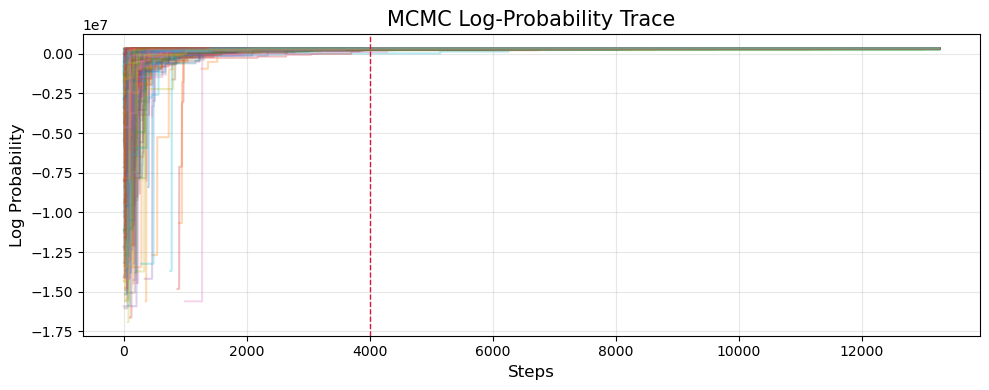

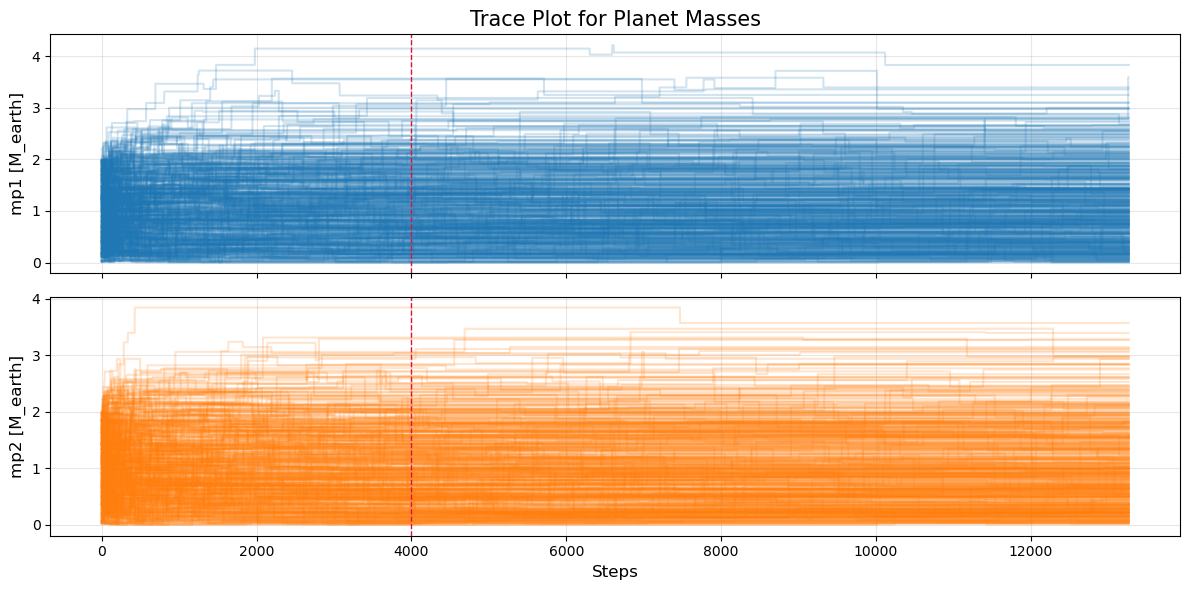

NameError: name 'labels' is not defined

In [5]:
# --- 10. 収束確認と主要パラメータの可視化 ---

# 1. 対数尤度 (Log-probability) の遷移プロット
log_prob = sampler.get_log_prob()
plt.figure(figsize=(10, 4))
plt.plot(log_prob, alpha=0.3)
plt.title("MCMC Log-Probability Trace", fontsize=15)
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Log Probability", fontsize=12)
plt.axvline(discard, color='crimson', linestyle='--', lw=1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. 惑星質量 (mp1, mp2) のトレースプロット
# mp1: Index 3, mp2: Index 10
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
samples_chain = sampler.get_chain()

axes[0].plot(samples_chain[:, :, 3], color="C0", alpha=0.2)
axes[0].set_ylabel("mp1 [M_earth]", fontsize=12)
axes[0].set_title("Trace Plot for Planet Masses", fontsize=15)
axes[0].axvline(discard, color='crimson', linestyle='--', lw=1)
axes[1].plot(samples_chain[:, :, 10], color="C1", alpha=0.2)
axes[1].set_ylabel("mp2 [M_earth]", fontsize=12)
axes[1].set_xlabel("Steps", fontsize=12)
axes[1].axvline(discard, color='crimson', linestyle='--', lw=1)

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 主要項目のコーナープロット
# 主要項目: lnrhos(0), b1(1), k1(2), mp1(3), P1(7), b2(8), k2(9), mp2(10), P2(14)
major_indices = [0, 1, 2, 3, 7, 8, 9, 10, 14]
major_labels = [labels[i] for i in major_indices]
major_samples = samples[:, major_indices]

fig = corner.corner(
    major_samples,
    labels=major_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".4f",
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    plot_datapoints=False,
    color="navy"
)
plt.show()